# Лабораторная работа 10

Тема: **Рекуррентные сети (LSTM/GRU) для классификации текстов в PyTorch**  
Цель: реализовать полный цикл решения задачи бинарной классификации текстов с помощью LSTM‑модели: от токенизации и построения словаря до обучения, валидации и анализа ошибок.

> Этот ноутбук оформлен как практическое задание.  
> Код даёт каркас, но основная часть баллов — за ваши собственные эксперименты и ваши пояснения.  
> Если вы попытаетесь автоматически сгенерировать весь текст отчёта, это будет заметно по стилю и несоответствию реальным графикам и числам.


## 1. Ваше исходное понимание задачи (обязательная текстовая часть)

Перед запуском кода зафиксируйте свои текущие представления (6–10 предложений):

1. Чем классификация текстов отличается от задач на изображения и табличные данные, с которыми вы уже работали.  
2. Зачем в текстовых задачах использовать рекуррентные сети (LSTM/GRU), а не просто среднее эмбеддингов слов с подачей в MLP.  
3. Как вы ожидаете, что **длина** текста и **порядок слов** повлияют на качество модели.

Пишите на своём языке, без попытки сделать "идеальное определение".


In [ ]:
intro_text = """1)Классификация текстов отличается от изображений и табличных данных тем, что текст - это последовательность слов (токенов).
  Они не являются фиксированной структорой, как например пиксели в изображениях или признаки в табличных данных.

2) Рекурентные сети позволяют учитывать как слова влияют друг на друга, их взаимосвязь между собой, последовательность или контекст.
  А среднее эмбеддингов слов теряют эту взаимосвязь, синтаксис.
  Например, "хочу в кино, не хочу в ресторан" эмбеддинг может перефразировать и потерять смысл "хочу в ресторан, не хочу в кино".

3) Я думаю, что чем длиннее текст, тем хуже будет качество модели.
  Должен быть баланс: на картоких текстах может быть недостаточно инофорации для классификации, а на длинных, наоборот, усложняют обучение.
  ПОрядок слов является критически важным для смысла, может поменяться смысл предложения, например, как в 2 вопросе.
"""
print(intro_text)

1)Классификация текстов отличается от изображений и табличных данных тем, что текст - это последовательность слов (токенов).
  Они не являются фиксированной структорой, как например пиксели в изображениях или признаки в табличных данных.

2) Рекурентные сети позволяют учитывать как слова влияют друг на друга, их взаимосвязь между собой, последовательность или контекст.
  А среднее эмбеддингов слов теряют эту взаимосвязь, синтаксис.
  Например, "хочу в кино, не хочу в ресторан" эмбеддинг может перефразировать и потерять смысл "хочу в ресторан, не хочу в кино".

3) Я думаю, что чем длиннее текст, тем хуже будет качество модели.
  Должен быть баланс: на картоких текстах может быть недостаточно инофорации для классификации, а на длинных, наоборот, усложняют обучение.
  ПОрядок слов является критически важным для смысла, может поменяться смысл предложения, например, как в 2 вопросе.



## 2. Импорт библиотек и настройка среды

Загрузим необходимые библиотеки, зафиксируем зерно случайности и определим устройство (`cpu` или `cuda`).


In [ ]:
import re
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

MY_SEED = 22
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 22


## 3. Пример простого текстового датасета

Для примера используем небольшой игрушечный датасет коротких предложений на английском с метками `0/1` (негатив/позитив).  
В **своей** лабораторной вы должны будете взять более содержательный и шумный датасет (реальные отзывы, комментарии и т.п.) - выберите какой-нибудь объект (фильм на кинопоиске, товар на озоне/вб, заведение на яндекс картах), скопируйте о нем отзывы, переведите на английский, раскидайте по  двум классам. Свой датасет соберите в отдельной новой ячейке.


In [ ]:
positive_sentences = [
    "I really liked this movie",
    "This film was great and inspiring",
    "What a fantastic experience",
    "I enjoyed every minute of it",
    "The actors did an amazing job",
    "Brilliant story and good pacing",
    "I would definitely watch it again",
    "It was funny and heartwarming",
    "A very beautiful and touching film",
    "Absolutely loved the characters"
]

negative_sentences = [
    "I really hated this movie",
    "This film was boring and slow",
    "What a terrible experience",
    "I regretted every minute of it",
    "The actors did a very bad job",
    "Awful story and strange pacing",
    "I would never watch it again",
    "It was dull and annoying",
    "A very ugly and pointless film",
    "Absolutely disliked the characters"
]

texts = positive_sentences + negative_sentences
labels = [1] * len(positive_sentences) + [0] * len(negative_sentences)

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(df.head())
print("Размер датасета:", df.shape)
print("Распределение классов:\n", df["label"].value_counts())

                                text  label
0          I really hated this movie      0
1      The actors did a very bad job      0
2           It was dull and annoying      0
3       I enjoyed every minute of it      1
4  This film was great and inspiring      1
Размер датасета: (20, 2)
Распределение классов:
 label
0    10
1    10
Name: count, dtype: int64


### Ваши замечания по датасету (обязательная мини‑секция)

Опишите (3–5 предложений):
- насколько базовый набор похож/не похож на реальные отзывы;  
- какие особенности реальных текстов в нем отсутствуют (длина, сленг, опечатки, смешение языков и т.п.);
- как эти отличия могут повлиять на результаты модели.


In [ ]:
data_comment = """набор в  целом похож на короткие комментарии, а не на отзывы, типа того, что говорят во время просмотра, так сказать короткий комментарий.
В нем отстуствуют длинные предложения, в основном все отзывы короткие и однообразные, нет слэнга, эмоджи.
Сами предложения без грамматических ошибок, без опечаток.
Для класса 1 есть противопоставляющий отзыв в классе 0.
В реальных отзывах обычно пишут более длинные отзывы, смешанные с описанием актеров, самого фильма, сценариев и тд.
Я думаю, что из-за этого модель может дать хорошие результаты на этом датасете, но при более сложных речевых оборотах будет сложнее.
"""
print(data_comment)

набор в  целом похож на короткие комментарии, а не на отзывы, типа того, что говорят во время просмотра, так сказать короткий комментарий.
В нем отстуствуют длинные предложения, в основном все отзывы короткие и однообразные, нет слэнга, эмоджи.
Сами предложения без грамматических ошибок, без опечаток.
Для класса 1 есть противопоставляющий отзыв в классе 0.
В реальных отзывах обычно пишут более длинные отзывы, смешанные с описанием актеров, самого фильма, сценариев и тд.
Я думаю, что из-за этого модель может дать хорошие результаты на этом датасете, но при более сложных речевых оборотах будет сложнее.



## 4. Токенизация, словарь и паддинг

Сделаем простую токенизацию:
- приведём текст к нижнему регистру;
- удалим лишние символы;
- разобьём строку на токены по пробелам.

Затем построим словарь и приведём все последовательности к одинаковой длине `max_len` с помощью паддинга.


In [ ]:
def simple_tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    return tokens

df["tokens"] = df["text"].apply(simple_tokenize)
print(df[["text", "tokens"]].head())

                                text                                    tokens
0          I really hated this movie           [i, really, hated, this, movie]
1      The actors did a very bad job     [the, actors, did, a, very, bad, job]
2           It was dull and annoying            [it, was, dull, and, annoying]
3       I enjoyed every minute of it       [i, enjoyed, every, minute, of, it]
4  This film was great and inspiring  [this, film, was, great, and, inspiring]


In [ ]:
# Подсчёт частот слов и построение словаря
word_counts = {}
for tokens in df["tokens"]:
    for w in tokens:
        word_counts[w] = word_counts.get(w, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in sorted_words:
    word2idx[w] = len(word2idx)

idx2word = {idx: w for w, idx in word2idx.items()}

print("Размер словаря:", len(word2idx))
print("Первые элементы словаря:", list(word2idx.items())[:10])

Размер словаря: 57
Первые элементы словаря: [('<PAD>', 0), ('<UNK>', 1), ('and', 2), ('i', 3), ('it', 4), ('a', 5), ('this', 6), ('the', 7), ('was', 8), ('film', 9)]


In [ ]:
def encode_tokens(tokens, word2idx):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

df["encoded"] = df["tokens"].apply(lambda t: encode_tokens(t, word2idx))
print(df[["tokens", "encoded"]].head())

lengths = df["encoded"].apply(len)
print("Мин и макс длины последовательностей:", lengths.min(), lengths.max())
max_len = int(lengths.max())  # для примера берём максимум
print("max_len =", max_len)

                                     tokens                     encoded
0           [i, really, hated, this, movie]          [3, 11, 28, 6, 12]
1     [the, actors, did, a, very, bad, job]  [7, 13, 14, 5, 10, 29, 15]
2            [it, was, dull, and, annoying]           [4, 8, 30, 2, 31]
3       [i, enjoyed, every, minute, of, it]      [3, 32, 16, 17, 18, 4]
4  [this, film, was, great, and, inspiring]        [6, 9, 8, 33, 2, 34]
Мин и макс длины последовательностей: 4 7
max_len = 7


In [ ]:
def pad_sequence(seq, max_len, pad_idx=0):
    if len(seq) < max_len:
        return seq + [pad_idx] * (max_len - len(seq))
    else:
        return seq[:max_len]

df["padded"] = df["encoded"].apply(lambda s: pad_sequence(s, max_len, pad_idx=word2idx["<PAD>"]))
print(df[["encoded", "padded"]].head())

                      encoded                      padded
0          [3, 11, 28, 6, 12]    [3, 11, 28, 6, 12, 0, 0]
1  [7, 13, 14, 5, 10, 29, 15]  [7, 13, 14, 5, 10, 29, 15]
2           [4, 8, 30, 2, 31]     [4, 8, 30, 2, 31, 0, 0]
3      [3, 32, 16, 17, 18, 4]   [3, 32, 16, 17, 18, 4, 0]
4        [6, 9, 8, 33, 2, 34]     [6, 9, 8, 33, 2, 34, 0]


### Мини‑вопрос

Ответьте коротко (2–4 предложения):
- какие последствия, по вашему мнению, будет иметь **слишком маленький** `max_len` на реальном датасете;  
- и какие - очень **большой** `max_len` (для обучения и оценки).


In [ ]:
padding_comment = """слишком маленький max_len может привести к потери контекста, из-за чего потеряется качество классифакации.
очень большой max_len может добавить много паддингов в словарь, что может замедлить обучение и потерять качество.
"""
print(padding_comment)

слишком маленький max_len может привести к потери контекста, из-за чего потеряется качество классифакации.
очень большой max_len может добавить много паддингов в словарь, что может замедлить обучение и потерять качество.



## 5. Разбиение на train/val/test и Dataset/DataLoader

Разобьём примеры на три части и подготовим `Dataset`/`DataLoader`.


In [ ]:
X = np.stack(df["padded"].values)
y = df["label"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=MY_SEED, stratify=y_temp
)

print("Размеры:")
print("  train:", X_train.shape)
print("  val  :", X_val.shape)
print("  test :", X_test.shape)

Размеры:
  train: (12, 7)
  val  : (4, 7)
  test : (4, 7)


In [ ]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

batch_size = 2
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 6


## 6. Модель: Embedding + LSTM + классификатор

Опишем базовую архитектуру:
- слой `Embedding` для кодирования токенов;
- один слой LSTM (можете заменить на GRU в своих экспериментах);
- полносвязный выход на 2 логита (для классов 0/1).


In [ ]:
vocab_size = len(word2idx)
embed_dim = 32
hidden_dim = 64
num_layers = 1
num_classes = 2

class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)              # [B, T] -> [B, T, E]
        output, (h_n, c_n) = self.lstm(emb)  # h_n: [L, B, H]
        last_hidden = h_n[-1]                # [B, H] — последнее по времени состояние верхнего слоя
        logits = self.fc(last_hidden)
        return logits

model = SimpleLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=word2idx["<PAD>"]
).to(device)

print(model)

SimpleLSTMClassifier(
  (embedding): Embedding(57, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


### Краткий комментарий по архитектуре

Ответьте в 3–5 предложениях:
- почему вы считаете, что такой размер эмбеддингов и скрытого слоя **достаточен/недостаточен** для этого игрушечного примера;  
- какие изменения архитектуры вы бы первыми попробовали при переходе к реальному датасету.


In [ ]:
arch_comment = """для игрушечных примеров достаточно небольшого размера эмбеддинга и скрытого слоя, при бОльшем количестве может быть переобучение.
Небольшие размеры позволяют быстрее обучаться, особенно на небольших примерах.
Данных размеров достаточно, больше точно не нужно, лучше даже меньше в несколько рах, у нас всего 20 предложений, в словаре 57 слов.
На реальном датасете, в первую очередьь я бы, наоборот, увеличила размеры. Можно было бы попровать поменять LSTM на GRU и сравнить.
"""
print(arch_comment)

для игрушечных примеров достаточно небольшого размера эмбеддинга и скрытого слоя, при бОльшем количестве может быть переобучение.
Небольшие размеры позволяют быстрее обучаться, особенно на небольших примерах.
Данных размеров достаточно, больше точно не нужно, лучше даже меньше в несколько рах, у нас всего 20 предложений, в словаре 57 слов.
На реальном датасете, в первую очередьь я бы, наоборот, увеличила размеры. Можно было бы попровать поменять LSTM на GRU и сравнить.



## 7. Функция потерь, оптимизатор и цикл обучения

Используем `CrossEntropyLoss` и `Adam`.  
Реализуем функции `train_one_epoch` и `evaluate`, затем запустим обучение.


In [ ]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [ ]:
num_epochs = 25
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Эпоха 1/25: train_loss=0.6919, train_acc=0.5000, val_loss=0.7021, val_acc=0.2500
Эпоха 2/25: train_loss=0.6796, train_acc=0.7500, val_loss=0.7133, val_acc=0.2500
Эпоха 3/25: train_loss=0.6639, train_acc=0.7500, val_loss=0.7227, val_acc=0.2500
Эпоха 4/25: train_loss=0.6527, train_acc=0.7500, val_loss=0.7368, val_acc=0.2500
Эпоха 5/25: train_loss=0.6372, train_acc=0.7500, val_loss=0.7549, val_acc=0.2500
Эпоха 6/25: train_loss=0.6188, train_acc=0.8333, val_loss=0.7815, val_acc=0.2500
Эпоха 7/25: train_loss=0.5918, train_acc=0.8333, val_loss=0.8146, val_acc=0.2500
Эпоха 8/25: train_loss=0.5648, train_acc=0.8333, val_loss=0.8682, val_acc=0.2500
Эпоха 9/25: train_loss=0.5259, train_acc=0.9167, val_loss=0.9488, val_acc=0.2500
Эпоха 10/25: train_loss=0.4709, train_acc=0.9167, val_loss=1.0565, val_acc=0.2500
Эпоха 11/25: train_loss=0.4024, train_acc=0.9167, val_loss=1.2145, val_acc=0.0000
Эпоха 12/25: train_loss=0.3137, train_acc=0.9167, val_loss=1.4704, val_acc=0.0000
Эпоха 13/25: train_loss=0

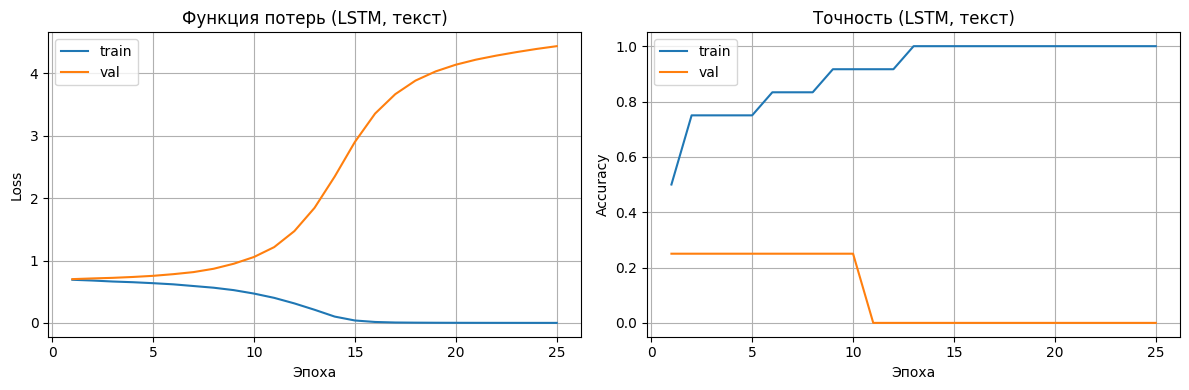

Финальные метрики: train_acc=1.0000, val_acc=0.0000


In [ ]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальные метрики: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- что происходит с точностью на **валидации**;
- есть ли заметный разрыв между train и val;
- что вы ожидаете увидеть на реальных данных при тех же настройках.


In [ ]:
training_comment = """Точность на валидации до 10 эпохи держится в 25%, а потом резко падает до 0 и не восстанавливается.
Это говорит о том, что модель на новых данных не обучает, зотя на тестовой выборке растет быстро до 100%.

Между train и val есть заметный разрыв и на потерях и на точности.
На потерях на валидационной выборке более 4.4306, а на тестовой падает до 0.
На точности, наоборот, train постепенно растет до 1.0, а val падает до 0.
Это также говорит о переобучение, модель запоминает обучающие примеры, но не учит устойчивые признаки.

Я ожидаю, что на реальных датасетах качество будет более плохое, так как там более сложные и длинные тексты.
"""
print(training_comment)

Точность на валидации до 10 эпохи держится в 25%, а потом резко падает до 0 и не восстанавливается.
Это говорит о том, что модель на новых данных не обучает, зотя на тестовой выборке растет быстро до 100%.

Между train и val есть заметный разрыв и на потерях и на точности.
На потерях на валидационной выборке более 4.4306, а на тестовой падает до 0.
На точности, наоборот, train постепенно растет до 1.0, а val падает до 0.
Это также говорит о переобучение, модель запоминает обучающие примеры, но не учит устойчивые признаки.

Я ожидаю, что на реальных датасетах качество будет более плохое, так как там более сложные и длинные тексты.



## 8. Оценка на тестовой выборке

Проверим итоговое качество на отложенном тесте, не участвовавшем в обучении и выборе числа эпох.


In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Качество на тесте: loss={test_loss:.4f}, accuracy={test_acc:.4f}")

Качество на тесте: loss=2.9511, accuracy=0.5000


## 9. Примеры предсказаний модели

Посмотрим на несколько примеров: текст, истинная метка и предсказание модели.


In [ ]:
model.eval()
idx_to_label = {0: "NEG", 1: "POS"}

def predict_single(text: str):
    tokens = simple_tokenize(text)
    encoded = encode_tokens(tokens, word2idx)
    padded = pad_sequence(encoded, max_len, pad_idx=word2idx["<PAD>"])
    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()
    return pred

print("Примеры из тестовой выборки:")
for i in range(min(5, len(X_test))):
    # восстановим текст по токенам (для простоты берём из исходного df)
    # здесь мы знаем, что первые len(X_train) строк относятся к train, остальные к temp
    text_tokens = df.iloc[i]["tokens"]
    text_str = " ".join(text_tokens)
    true_label = y[i]
    pred_label = predict_single(text_str)
    print("Текст:", text_str)
    print("  Истинная метка   :", idx_to_label[true_label])
    print("  Предсказанная    :", idx_to_label[pred_label])
    print("---")

Примеры из тестовой выборки:
Текст: i really hated this movie
  Истинная метка   : NEG
  Предсказанная    : POS
---
Текст: the actors did a very bad job
  Истинная метка   : NEG
  Предсказанная    : NEG
---
Текст: it was dull and annoying
  Истинная метка   : NEG
  Предсказанная    : NEG
---
Текст: i enjoyed every minute of it
  Истинная метка   : POS
  Предсказанная    : POS
---


### Комментарий по предсказаниям

Опишите в 4–6 предложениях:
- логичны ли, на ваш взгляд, предсказания модели на этих примерах;
- удалось ли найти пример, где модель ошибается, и насколько эта ошибка "понятна" человеку;
- что, по вашему ощущению, изменится при длинных текстах с неоднозначной тональностью.


In [ ]:
pred_comment = """На мой взгляд, предсказание модели частично логичны: модель правильно классифицирофала 3 из 4 примеров.
В предложение "i really hated this movie" модель предсказала позитивный класс, хотя явно присутсвует негавтиное слово.
Для человека такая ошибка понятна, модель, скорее всего, зацепилась за слово 'really', поэтому неправильнь поняла формулировку, упустив негативную тональность в слове 'hated'.
Также модель могла просто переобучиться на ограниченном наборе.
По моим ощущениям, на длинных текстах с неоднозначной тональностью, модель будет ошибаться еще чаще, чем в таких коротких примерах.
Изначально модель обучилась на коротких и однозначных примерах, не научившись сравнивать неоднозначные примеры с разными тональностями и контекстами.
"""
print(pred_comment)

На мой взгляд, предсказание модели частично логичны: модель правильно классифицирофала 3 из 4 примеров.
В предложение "i really hated this movie" модель предсказала позитивный класс, хотя явно присутсвует негавтиное слово.
Для человека такая ошибка понятна, модель, скорее всего, зацепилась за слово 'really', поэтому неправильнь поняла формулировку, упустив негативную тональность в слове 'hated'.
Также модель могла просто переобучиться на ограниченном наборе.
По моим ощущениям, на длинных текстах с неоднозначной тональностью, модель будет ошибаться еще чаще, чем в таких коротких примерах.
Изначально модель обучилась на коротких и однозначных примерах, не научившись сравнивать неоднозначные примеры с разными тональностями и контекстами.



## 10. Идеи для самостоятельных вариаций (для вашей работы со своим датасетом)

В своей версии лабораторной работы вы должны будете:
- взять **реальный** текстовый датасет (отзывы, комментарии, заголовки новостей и т.п.);
- реализовать ту же цепочку: токенизация → словарь → паддинг → LSTM/GRU;
- поэкспериментировать минимум с двумя архитектурами (например, LSTM vs GRU, 1 vs 2 слоя, разный `hidden_dim`/`embed_dim`);
- сравнить результаты по валидaции/тесту и описать найденные закономерности.

Этот ноутбук даёт только пример на упрощённых данных. Ваш основной вклад - перенос идеи на реальную задачу и её качественный анализ.


## Ниже реалзуйте обучение на своём датасете
У вас всё получится! (быстро же всё обучается)

In [ ]:
# Заглушка под ваш код

# Место для вашего датасета
my_positive_sentences = [
    "Cool"
]

my_negative_sentences = [
    "Not cool"
]

my_texts = my_positive_sentences + my_negative_sentences
my_labels = [1] * len(my_positive_sentences) + [0] * len(my_negative_sentences)

my_df = pd.DataFrame({"text": my_texts, "label": my_labels})
my_df = my_df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(my_df.head())
print("Размер датасета:", my_df.shape)
print("Распределение классов:\n", my_df["label"].value_counts())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
                                                text  label
0  The other day I showed my boyfriend a great mo...      0
1  let me say that i love Adam Sandler, watching ...      1
2  This movie had me going. The title was perhaps...      0
3  SPOILER Wolfcreek meets Texas Chainsaw Massacr...      0
4  What a great film it is. The notion of nations...      1
Размер датасета: (1000, 2)
Распределение классов:
 label
0    527
1    473
Name: count, dtype: int64


In [ ]:
final_summary = """СВОЙ ДАТАСЕТ Я РЕАЛИЗОВАЛА В ФАЙЛЕ lab10_task_KII_MY_DF.ipynb
"""
print(final_summary)

СВОЙ ДАТАСЕТ Я РЕАЛИЗОВАЛА В ФАЙЛЕ lab10_task_KII_MY_DF.ipynb

